# PRM-02 · Quantitative Portfolio Management — practice notebook
**Instructor:** Jay Parmar  ·  **Rebuilt on the real shipped Indian-equity data.**

This notebook reproduces the lecture end to end on the data that ships in
`PRM02-Inclass-Exercises-File.zip`: daily OHLCV for **TCS** (IT), **MARUTI** (auto) and
**MARICO** (FMCG) from Jan-2015 to Aug-2020, the **Nifty 50 benchmark**, and a
**49-stock Nifty 50 price matrix**. Every number below is computed from these files — no
synthetic data.

**Road map** — the three questions every portfolio manager answers *from the data*:
1. A single stock, from two angles (returns & risk).
2. A two-stock portfolio → Markowitz's covariance insight → correlation.
3. The diversification limit → the efficient frontier → an out-of-sample backtest.
4. Profitability analysis: Sharpe, Sortino, Treynor, Calmar, Information ratios (+ VaR/CVaR, Kelly).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)
pd.options.display.precision = 4

def load(name, price_col="Adj Close"):
    df = pd.read_csv(name, index_col=0, parse_dates=True)
    df["returns"] = df[price_col].pct_change()
    df.dropna(inplace=True)
    return df

print("data files:", [f for f in os.listdir('.') if f.endswith('.csv')])


data files: ['Benchmark.csv', 'MARICO.csv', 'MARUTI.csv', 'nifty50.csv', 'TCS.csv']


## 1 · One stock from two angles — returns and risk

We always study an instrument from **two perspectives: returns and risk.** Start with **TCS**,
an IT giant, using its adjusted close so that dividends and splits are already handled.

**Four return statistics, each a different question:**
* **Single-period return** — one day's move, `(Pₜ − Pₜ₋₁)/Pₜ₋₁`.
* **Holding-period (cumulative) return** — chain them, `∏(1+rₜ) − 1`: *where did it end up?*
* **Arithmetic mean × 252** — the *typical year*; simple and additive → used for **analysis**.
* **Geometric / CAGR** — `(1+cum)^(252/N) − 1`; accounts for compounding → what funds **publish**.


In [2]:
tcs = load("TCS.csv")

# single-period return (last day)
spr = (tcs['Adj Close'].iloc[-1] - tcs['Adj Close'].iloc[-2]) / tcs['Adj Close'].iloc[-2]
print("Single-period (last day) return: %.4f%%" % (spr*100))

def return_stats(r, name):
    cum = (1+r).cumprod() - 1
    net = cum.iloc[-1]
    daily_mean = r.mean()
    annual_mean = daily_mean * 252
    cagr = (1+net)**(252/len(r)) - 1
    print(f"\n{name} ({len(r)} days)")
    print(f"  cumulative (HPR)     : {net*100:8.3f}%")
    print(f"  daily mean           : {daily_mean*100:8.4f}%")
    print(f"  annual mean (x252)   : {annual_mean*100:8.4f}%   <- for analysis")
    print(f"  CAGR (geometric)     : {cagr*100:8.3f}%   <- for publishing")
    return annual_mean, cagr, cum

tcs_amean, tcs_cagr, tcs_cum = return_stats(tcs['returns'], "TCS")


Single-period (last day) return: -0.4381%

TCS (1392 days)
  cumulative (HPR)     :  105.546%
  daily mean           :   0.0641%
  annual mean (x252)   :  16.1600%   <- for analysis
  CAGR (geometric)     :   13.932%   <- for publishing


### Risk — variance and volatility

Returns hide the **path**: +105% earned smoothly is very different from the same number earned
by lurching. **Variance** measures how far daily returns spread from their mean (units of
"%-squared", opaque, but *additive & comparable* → good for analysis). Its square root is the
**standard deviation / volatility** — human-readable. We annualise variance by ×252 and
volatility by ×√252.


In [3]:
def risk_stats(r, name):
    daily_var = r.var()
    annual_var = daily_var * 252
    daily_std = r.std()
    annual_std = daily_std * np.sqrt(252)
    print(f"{name}: annual variance {annual_var:.4f} | annual volatility {annual_std*100:.4f}%")
    return annual_var, annual_std

tcs_avar, tcs_avol = risk_stats(tcs['returns'], "TCS")
print("\n=> To earn ~%.1f%% a year in TCS you must stomach ~%.1f%% volatility. A single stock is risky." 
      % (tcs_amean*100, tcs_avol*100))


TCS: annual variance 0.0623 | annual volatility 24.9605%

=> To earn ~16.2% a year in TCS you must stomach ~25.0% volatility. A single stock is risky.


## 2 · A second stock — MARUTI

Add an auto name, **MARUTI**. It earns *more* but also swings *harder* — on its own it does not
solve the problem. The point of the next section is that holding **both** can beat either.

In [4]:
maruti = load("MARUTI.csv")
mar_amean, mar_cagr, mar_cum = return_stats(maruti['returns'], "MARUTI")
mar_avar, mar_avol = risk_stats(maruti['returns'], "MARUTI")

comparison = pd.DataFrame(index=['TCS','MARUTI'])
comparison['annual_mean_%']  = [tcs_amean*100, mar_amean*100]
comparison['annual_vol_%']   = [tcs_avol*100,  mar_avol*100]
comparison.round(3)



MARUTI (1392 days)
  cumulative (HPR)     :  126.548%
  daily mean           :   0.0771%
  annual mean (x252)   :  19.4168%   <- for analysis
  CAGR (geometric)     :   15.957%   <- for publishing
MARUTI: annual variance 0.0921 | annual volatility 30.3454%


,annual_mean_%,annual_vol_%
TCS,16.160,24.961
MARUTI,19.417,30.345


## 3 · Two stocks are better than one — the Markowitz insight

**Portfolio return is easy — a weighted sum:**  `rₚ = wₐ·rₐ + w_b·r_b`.  Half TCS + half MARUTI.

**Portfolio risk is where the Nobel Prize lives.** Your first guess — that portfolio variance is
just the weighted sum of individual variances — is *wrong*. Harry Markowitz (1952) showed that
stocks **move together**, and that co-movement changes combined risk:

$$\sigma_p^2 = w_a^2\sigma_a^2 + w_b^2\sigma_b^2 + 2\,w_a w_b\,\mathrm{cov}(a,b)$$

For any number of assets this collapses to the matrix form `σ²ₚ = w · Σ · wᵀ`.

In [5]:
w = np.array([0.5, 0.5])

# expected portfolio return
port_return = np.dot(w, [tcs_amean, mar_amean])
print("Expected annual portfolio return (TCS+MARUTI 50/50): %.3f%%" % (port_return*100))

# annual variance-covariance matrix
cov_tm = np.cov(tcs['returns'], maruti['returns']) * 252
cov_df = pd.DataFrame(cov_tm, index=['TCS','MARUTI'], columns=['TCS','MARUTI'])
print("\nAnnual variance-covariance matrix:")
print(cov_df.round(4))

# first principles
var_fp = (0.5**2)*cov_tm[0,0] + (0.5**2)*cov_tm[1,1] + 2*0.5*0.5*cov_tm[0,1]
# matrix form
var_mat = w.T.dot(cov_tm).dot(w)
print("\nportfolio variance (first principles) : %.5f" % var_fp)
print("portfolio variance (matrix w.Σ.wᵀ)   : %.5f" % var_mat)
port_vol = np.sqrt(var_mat)
print("portfolio volatility  : %.4f%%" % (port_vol*100))
print("\n=> %.2f%% sits BELOW both %.2f%% (TCS) and %.2f%% (MARUTI) — diversification, the free lunch."
      % (port_vol*100, tcs_avol*100, mar_avol*100))


Expected annual portfolio return (TCS+MARUTI 50/50): 17.788%

Annual variance-covariance matrix:
           TCS  MARUTI
TCS     0.0623  0.0189
MARUTI  0.0189  0.0921

portfolio variance (first principles) : 0.04805
portfolio variance (matrix w.Σ.wᵀ)   : 0.04805
portfolio volatility  : 21.9211%

=> 21.92% sits BELOW both 24.96% (TCS) and 30.35% (MARUTI) — diversification, the free lunch.


### Correlation — the standardised co-movement

Covariance is unbounded and hard to read, so we standardise it into **correlation** in [−1, 1]:
`corr(x,y) = cov(x,y) / (σₓ·σᵧ)`. The variance formula says *lower correlation → lower combined
risk*, so the natural move is to hunt for a stock **less** correlated with what we already hold.

In [6]:
corr_tm = np.corrcoef(tcs['returns'], maruti['returns'])[0, 1]
print("Correlation TCS vs MARUTI: %.3f" % corr_tm)


Correlation TCS vs MARUTI: 0.250


## 4 · The secret ingredient is low correlation — add MARICO

Swap in an FMCG name, **MARICO**, whose correlation with TCS is much lower. Rebuild the 50/50
portfolio: the volatility drops **further**, while the return barely suffers.

In [7]:
marico = load("MARICO.csv")
mrc_amean, mrc_cagr, mrc_cum = return_stats(marico['returns'], "MARICO")
mrc_avar, mrc_avol = risk_stats(marico['returns'], "MARICO")

corr_tmrc = np.corrcoef(tcs['returns'], marico['returns'])[0, 1]
cov_tmrc = np.cov(tcs['returns'], marico['returns']) * 252
w = np.array([0.5, 0.5])
port_vol_mrc = np.sqrt(w.T.dot(cov_tmrc).dot(w))
port_ret_mrc = np.dot(w, [tcs_amean, mrc_amean])

print("\n%-14s corr=%.3f  ->  50/50 vol %.2f%%, return %.2f%%" % ("TCS+MARUTI", corr_tm, port_vol*100, port_return*100))
print("%-14s corr=%.3f  ->  50/50 vol %.2f%%, return %.2f%%" % ("TCS+MARICO", corr_tmrc, port_vol_mrc*100, port_ret_mrc*100))
print("\n=> Lower correlation (%.3f < %.3f) pushes portfolio volatility down further. Hold UNCORRELATED names." 
      % (corr_tmrc, corr_tm))



MARICO (1392 days)
  cumulative (HPR)     :  152.853%
  daily mean           :   0.0803%
  annual mean (x252)   :  20.2325%   <- for analysis
  CAGR (geometric)     :   18.286%   <- for publishing
MARICO: annual variance 0.0688 | annual volatility 26.2345%

TCS+MARUTI     corr=0.250  ->  50/50 vol 21.92%, return 17.79%
TCS+MARICO     corr=0.119  ->  50/50 vol 19.15%, return 18.20%

=> Lower correlation (0.119 < 0.250) pushes portfolio volatility down further. Hold UNCORRELATED names.


## 5 · How far can diversification take us?

If one uncorrelated stock helps, why not ten or fifty? Take the shipped **49-stock Nifty 50
matrix**, build equal-weight portfolios of growing size (1, 2, 3, … 49 names) and watch the
volatility. Three lessons emerge: it falls fast at first, then flattens, and **never reaches
zero**.

In [8]:
nifty = pd.read_csv("nifty50.csv", index_col=0, parse_dates=True, dayfirst=True)
nret = nifty.pct_change().dropna(axis=1, how='all')
print("Nifty matrix: %d days x %d stocks" % nret.shape)

sd = {}
for k in range(1, len(nret.columns)+1):
    ww = np.full(k, 1/k)
    cm = nret.iloc[:, :k].cov() * 252
    sd[k] = np.sqrt(ww.T.dot(cm).dot(ww)) * 100
sd = pd.Series(sd)
for k in [1,2,3,5,8,10,20,30,49]:
    print(f"  {k:2d} stocks : {sd[k]:6.2f}%  volatility")
print("\n=> Falls fast, flattens (~elbow at a handful of names), never reaches zero.")


Nifty matrix: 1393 days x 49 stocks


   1 stocks :  36.18%  volatility
   2 stocks :  25.48%  volatility
   3 stocks :  25.32%  volatility
   5 stocks :  23.55%  volatility
   8 stocks :  22.48%  volatility
  10 stocks :  20.55%  volatility
  20 stocks :  18.85%  volatility
  30 stocks :  18.61%  volatility
  49 stocks :  18.03%  volatility

=> Falls fast, flattens (~elbow at a handful of names), never reaches zero.


### Two kinds of risk — why there is a floor

$$\text{Total risk} = \text{Unsystematic (diversifiable)} + \text{Systematic (market)}$$

**Unsystematic risk** is company-specific (fraud, a bad quarter) — exactly what diversification
cancels. **Systematic risk** is market-wide (recessions, rate moves, pandemics) — it hits
everything at once, so it cannot be diversified away, only hedged. The flat tail of the curve
**is** that systematic floor.

In [9]:
print("systematic floor (all %d names, equal weight): %.2f%% volatility" % (len(nret.columns), sd[len(nret.columns)]))
print("=> below this you cannot go by diversification alone; only hedging removes systematic risk.")


systematic floor (all 49 names, equal weight): 18.03% volatility
=> below this you cannot go by diversification alone; only hedging removes systematic risk.


## 6 · In what proportion? The efficient frontier (Monte Carlo)

Equal weights are rarely optimal. Following the lecture, pick **six** low-correlation names
— CIPLA, EICHERMOT, COALINDIA, HINDUNILVR, NESTLEIND, ONGC — and simulate **3,500 long-only
portfolios** whose weights are drawn from a **Dirichlet** distribution (each vector sums to 1,
all positive — Indian markets bar overnight shorting). Plot return vs volatility: the upper-left
edge of the cloud is the **efficient frontier**.

In [10]:
new_stocks = ['CIPLA','EICHERMOT','COALINDIA','HINDUNILVR','NESTLEIND','ONGC']
psr = nret[new_stocks].dropna()
annual_mean_returns = psr.mean() * 252
annual_cov = psr.cov() * 252

np.random.seed(11)
weights = np.random.dirichlet(np.ones(len(new_stocks)), size=3500)

port_ret = np.dot(weights, annual_mean_returns) * 100
port_vol_all = np.array([np.sqrt(x.T.dot(annual_cov).dot(x)) for x in weights]) * 100
ratio = port_ret / port_vol_all       # return per unit risk (Sharpe with rf=0)

imin = port_vol_all.argmin()
imax = ratio.argmax()
imaxret = port_ret.argmax()

print("Simulated %d long-only portfolios of %d stocks" % (len(weights), len(new_stocks)))
print("\nMinimum-volatility portfolio : vol %.2f%%  return %.2f%%" % (port_vol_all[imin], port_ret[imin]))
print("  weights:", ", ".join("%s %.1f%%" % (s, weights[imin,i]*100) for i,s in enumerate(new_stocks)))
print("\nMaximum-Sharpe portfolio     : vol %.2f%%  return %.2f%%  ratio %.3f" % (port_vol_all[imax], port_ret[imax], ratio[imax]))
print("  weights:", ", ".join("%s %.1f%%" % (s, weights[imax,i]*100) for i,s in enumerate(new_stocks)))
print("\nMaximum-return portfolio     : vol %.2f%%  return %.2f%%" % (port_vol_all[imaxret], port_ret[imaxret]))
print("\n=> Endowment picks the min-vol corner; a balanced fund the max-Sharpe; an aggressive fund the max-return.")


Simulated 3500 long-only portfolios of 6 stocks

Minimum-volatility portfolio : vol 16.91%  return 13.21%
  weights: CIPLA 25.1%, EICHERMOT 6.5%, COALINDIA 14.2%, HINDUNILVR 25.0%, NESTLEIND 26.0%, ONGC 3.2%

Maximum-Sharpe portfolio     : vol 18.87%  return 19.87%  ratio 1.053
  weights: CIPLA 5.0%, EICHERMOT 14.1%, COALINDIA 0.2%, HINDUNILVR 44.0%, NESTLEIND 33.7%, ONGC 3.1%

Maximum-return portfolio     : vol 21.35%  return 21.03%

=> Endowment picks the min-vol corner; a balanced fund the max-Sharpe; an aggressive fund the max-return.


## 7 · Does it hold up out of sample?

A backtest on the data you optimised on always looks good; the honest test is **fresh data**.
Split the six-stock history into an in-sample period (first 70%) to build the frontier and a
held-out out-of-sample period (last 30%). Compare **equal-weight** against the **max-Sharpe**
optimised weights on the unseen window.

In [11]:
split = int(len(psr) * 0.70)
train, test = psr.iloc[:split], psr.iloc[split:]

# optimise on the training window only
amr_t = train.mean() * 252
acov_t = train.cov() * 252
np.random.seed(11)
Wt = np.random.dirichlet(np.ones(len(new_stocks)), size=3500)
ratio_t = np.dot(Wt, amr_t) / np.array([np.sqrt(x.T.dot(acov_t).dot(x)) for x in Wt])
opt_w = Wt[ratio_t.argmax()]
eq_w = np.full(len(new_stocks), 1/len(new_stocks))

eq_curve  = (1 + (test * eq_w).sum(axis=1)).cumprod()
opt_curve = (1 + (test * opt_w).sum(axis=1)).cumprod()
print("Out-of-sample window: %d days (%s -> %s)" % (len(test), test.index[0].date(), test.index[-1].date()))
print("  equal-weight cumulative return     : %.2f%%" % ((eq_curve.iloc[-1]-1)*100))
print("  max-Sharpe optimised cumulative    : %.2f%%" % ((opt_curve.iloc[-1]-1)*100))
print("\n=> Optimised weights can edge ahead, but the in-sample advantage compresses. Markets change")
print("   regime, so PMs REBALANCE periodically to stay close to the backtest.")


Out-of-sample window: 418 days (2018-12-14 -> 2020-08-27)


  equal-weight cumulative return     : 8.94%
  max-Sharpe optimised cumulative    : 28.12%

=> Optimised weights can edge ahead, but the in-sample advantage compresses. Markets change
   regime, so PMs REBALANCE periodically to stay close to the backtest.


## 8 · Profitability analysis — risk-adjusted return ratios

A raw return means little without the risk taken to earn it. Each ratio below is *excess return
per unit of a different risk measure*. We compute them for **TCS vs the Nifty 50 benchmark**,
with the risk-free rate set to 0 (as in the shipped notebook), annualising by √252.

| Ratio | Risk in the denominator |
|---|---|
| **Sharpe** | total volatility σ |
| **Sortino** | downside deviation (negative returns only) |
| **Treynor** | β (systematic risk vs the market) |
| **Calmar** | maximum drawdown |
| **Information** | tracking error (std of return − benchmark) |


In [12]:
benchmark = load("Benchmark.csv", price_col="Close")
rf = 0.00
r = tcs['returns']

# Sharpe
sharpe = (r - rf).mean() / r.std() * np.sqrt(252)

# Sortino - downside deviation
ex = r - rf
sortino = ex.mean() / ex[ex < 0].std() * np.sqrt(252)

# Treynor - needs beta vs benchmark
common = tcs.index.intersection(benchmark.index)
cov_mb = np.cov(tcs.loc[common,'returns'], benchmark.loc[common,'returns'])[0,1] * 252
beta = cov_mb / (benchmark.loc[common,'returns'].var() * 252)
treynor = (r.mean() - rf/252) / beta * np.sqrt(252)

# Calmar - annualised return / abs(max drawdown)
cumprod_ret = (r + 1).cumprod() * 100
trough = (np.maximum.accumulate(cumprod_ret) - cumprod_ret).idxmax()
peak = cumprod_ret.loc[:trough].idxmax()
mdd = 100 * (cumprod_ret[trough] - cumprod_ret[peak]) / cumprod_ret[peak]
calmar = (tcs_cagr*100) / abs(mdd)

# Information ratio - excess over benchmark / tracking error
exb = tcs.loc[common,'returns'] - benchmark.loc[common,'returns']
info = exb.mean() / exb.std() * np.sqrt(252)

print("TCS risk-adjusted performance (rf = 0, benchmark = Nifty 50):")
print(f"  Sharpe ratio       : {sharpe:5.2f}")
print(f"  Sortino ratio      : {sortino:5.2f}   (rewards it for low DOWNSIDE volatility)")
print(f"  Beta vs Nifty      : {beta:5.2f}")
print(f"  Treynor ratio      : {treynor:5.2f}")
print(f"  Maximum drawdown   : {mdd:6.2f}%")
print(f"  Calmar ratio       : {calmar:5.2f}")
print(f"  Information ratio   : {info:5.2f}   (0.4-0.6 is good; >1 is rare)")


TCS risk-adjusted performance (rf = 0, benchmark = Nifty 50):
  Sharpe ratio       :  0.65
  Sortino ratio      :  0.93   (rewards it for low DOWNSIDE volatility)
  Beta vs Nifty      :  0.63
  Treynor ratio      :  0.02
  Maximum drawdown   : -27.21%
  Calmar ratio       :  0.51
  Information ratio   :  0.36   (0.4-0.6 is good; >1 is rare)


### Bonus from the summary — tail risk (VaR / CVaR) and position sizing (Kelly)

The summary document adds two more tools. **Value at Risk (VaR)** is the loss threshold at a
confidence level; **Expected Shortfall / CVaR** is the *average* loss once you breach it (it also
tells you the *size* of the tail, which VaR does not). **Kelly** gives the growth-optimal bet
fraction; for a strategy with mean μ and variance σ² it is `f = (μ − r)/σ²`. Many traders use a
*fraction* of Kelly because it ignores drawdowns.

In [13]:
# Historical VaR / CVaR on TCS daily returns
alpha = 0.05
var95 = np.percentile(r, alpha*100)
cvar95 = r[r <= var95].mean()
print("Daily VaR (95%%): %.2f%%   -> on the worst 5%% of days you lose at least this" % (var95*100))
print("Daily CVaR/ES (95%%): %.2f%%   -> the AVERAGE loss on those tail days" % (cvar95*100))

# Kelly fraction (continuous form) using annualised stats
kelly = (tcs_amean - rf) / tcs_avar
print("\nKelly fraction f = (mu - r)/sigma^2 for TCS: %.2f" % kelly)
print("(>1 implies leverage; most traders bet a fraction of Kelly because it ignores drawdowns.)")


Daily VaR (95%): -2.42%   -> on the worst 5% of days you lose at least this
Daily CVaR/ES (95%): -3.53%   -> the AVERAGE loss on those tail days

Kelly fraction f = (mu - r)/sigma^2 for TCS: 2.59
(>1 implies leverage; most traders bet a fraction of Kelly because it ignores drawdowns.)


## 9 · Four pictures of portfolio construction

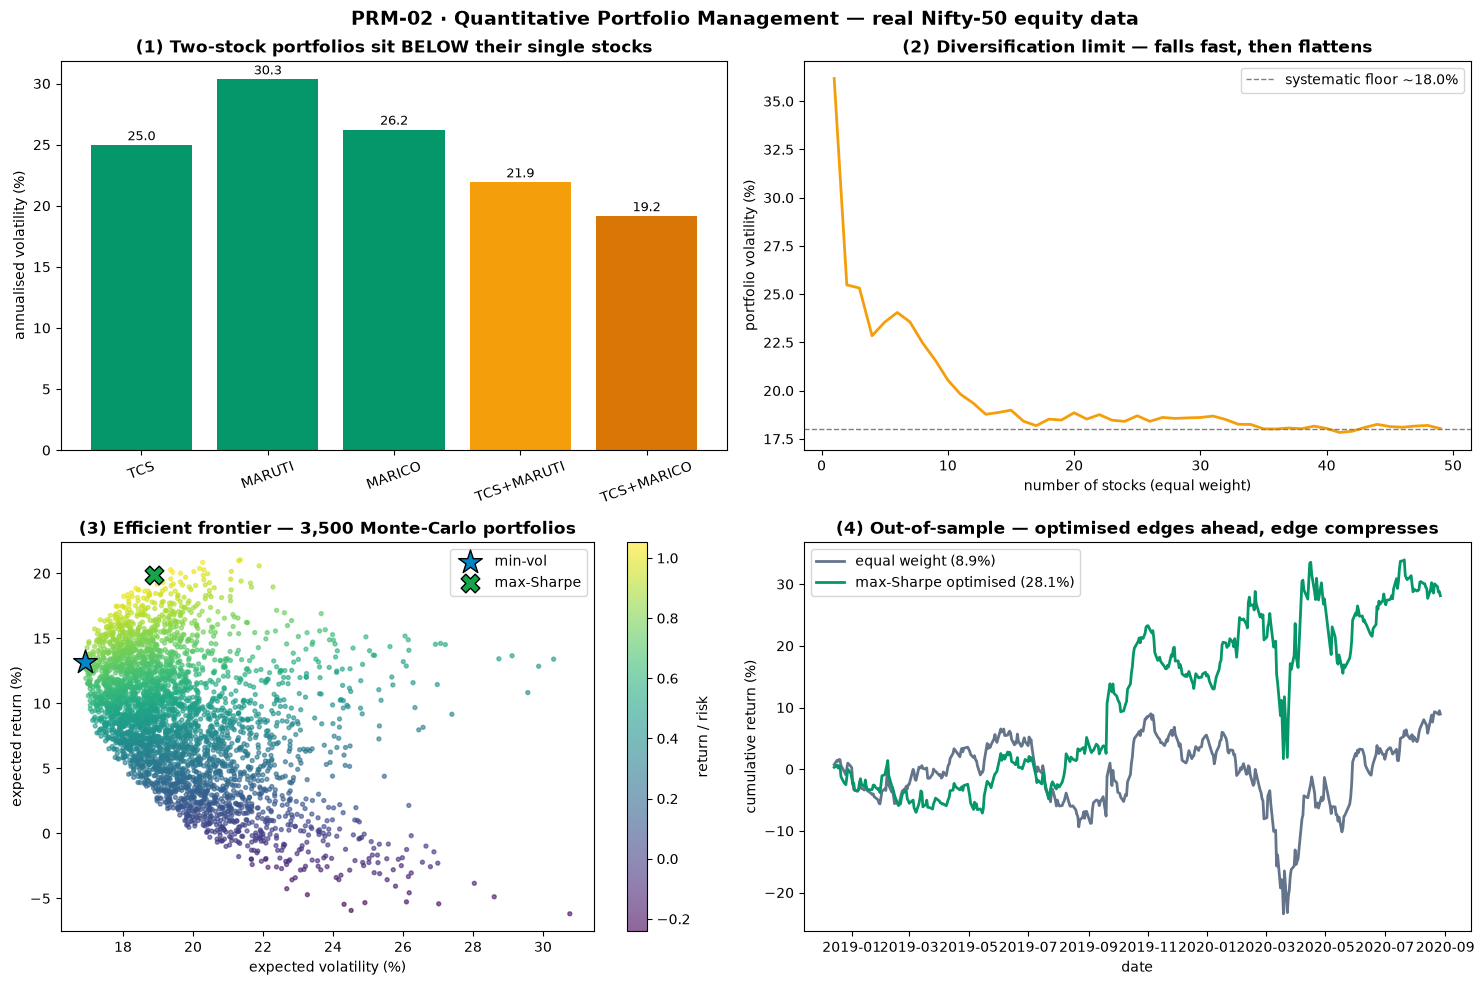

saved chart_1_portfolio.png


In [14]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# (1) portfolio volatility below single stocks
labels = ['TCS','MARUTI','MARICO','TCS+MARUTI','TCS+MARICO']
vols   = [tcs_avol*100, mar_avol*100, mrc_avol*100, port_vol*100, port_vol_mrc*100]
colors = ['#059669','#059669','#059669','#f59e0b','#d97706']
ax[0,0].bar(labels, vols, color=colors)
ax[0,0].set_title('(1) Two-stock portfolios sit BELOW their single stocks', fontweight='bold')
ax[0,0].set_ylabel('annualised volatility (%)')
ax[0,0].tick_params(axis='x', rotation=20)
for i,v in enumerate(vols): ax[0,0].text(i, v+0.4, f'{v:.1f}', ha='center', fontsize=9)

# (2) diversification curve
ax[0,1].plot(sd.index, sd.values, color='#f59e0b', lw=2)
ax[0,1].axhline(sd[len(nret.columns)], ls='--', color='gray', lw=1, label=f'systematic floor ~{sd[len(nret.columns)]:.1f}%')
ax[0,1].set_title('(2) Diversification limit — falls fast, then flattens', fontweight='bold')
ax[0,1].set_xlabel('number of stocks (equal weight)'); ax[0,1].set_ylabel('portfolio volatility (%)')
ax[0,1].legend()

# (3) efficient frontier
sc = ax[1,0].scatter(port_vol_all, port_ret, c=ratio, cmap='viridis', s=8, alpha=0.6)
ax[1,0].scatter(port_vol_all[imin], port_ret[imin], marker='*', s=320, c='#0284c7', edgecolor='k', label='min-vol', zorder=5)
ax[1,0].scatter(port_vol_all[imax], port_ret[imax], marker='X', s=180, c='#16a34a', edgecolor='k', label='max-Sharpe', zorder=5)
ax[1,0].set_title('(3) Efficient frontier — 3,500 Monte-Carlo portfolios', fontweight='bold')
ax[1,0].set_xlabel('expected volatility (%)'); ax[1,0].set_ylabel('expected return (%)')
ax[1,0].legend(); fig.colorbar(sc, ax=ax[1,0], label='return / risk')

# (4) out-of-sample backtest
ax[1,1].plot(eq_curve.index, (eq_curve-1)*100, color='#64748b', lw=2, label=f'equal weight ({(eq_curve.iloc[-1]-1)*100:.1f}%)')
ax[1,1].plot(opt_curve.index, (opt_curve-1)*100, color='#059669', lw=2, label=f'max-Sharpe optimised ({(opt_curve.iloc[-1]-1)*100:.1f}%)')
ax[1,1].set_title('(4) Out-of-sample — optimised edges ahead, edge compresses', fontweight='bold')
ax[1,1].set_xlabel('date'); ax[1,1].set_ylabel('cumulative return (%)'); ax[1,1].legend()

plt.suptitle('PRM-02 · Quantitative Portfolio Management — real Nifty-50 equity data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_1_portfolio.png', dpi=110, bbox_inches='tight')
plt.show()
print("saved chart_1_portfolio.png")


## 10 · Recap — the portfolio manager's chain of decisions

1. **Define the objective** — it sets the asset universe (preserve vs grow capital).
2. Analyse every instrument from **two angles**: returns (arithmetic for analysis, CAGR to
   publish) and risk (variance for analysis, volatility to publish).
3. A single stock is too risky (TCS ~16% return for ~25% vol).
4. Portfolio **return = weighted sum**; **variance = w·Σ·wᵀ** — covariance matters (Markowitz).
5. Hold **uncorrelated** securities — lower correlation drives combined risk down.
6. Diversification has a **limit** — a systematic floor it cannot cross, only hedge.
7. Optimise weights on the **efficient frontier** (min-vol / max-Sharpe / max-return by objective).
8. **Backtest out of sample and rebalance** — the in-sample edge always compresses.
9. Judge performance with **risk-adjusted ratios** (Sharpe/Sortino/Treynor/Calmar/Information),
   watch **tail risk** (VaR/CVaR), and size positions with **Kelly** (usually a fraction of it).

The mathematics is identical whether the universe is Indian equities, ETFs, commodities, or a
stable of strategies — these ideas are *instrument-agnostic*. The edge lives in the choice of
universe and the constraints layered on top.